
--- Processing SPCID Pipeline ---

[GA] Optimizing features for SPCID...
  Generation 1: Best MAE = 2287.75
  Generation 2: Best MAE = 2287.75
  Generation 3: Best MAE = 2287.75
  Generation 4: Best MAE = 2287.75
  Generation 5: Best MAE = 2287.75


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Processing SDEDD Pipeline ---

[GA] Optimizing features for SDEDD...
  Generation 1: Best MAE = 1347.14
  Generation 2: Best MAE = 1347.14
  Generation 3: Best MAE = 1347.14
  Generation 4: Best MAE = 1347.14
  Generation 5: Best MAE = 1347.14


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Processing ASPPD Pipeline ---

[GA] Optimizing features for ASPPD...
  Generation 1: Best MAE = 3588.54
  Generation 2: Best MAE = 3588.54
  Generation 3: Best MAE = 3588.54
  Generation 4: Best MAE = 3588.54
  Generation 5: Best MAE = 3588.54


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


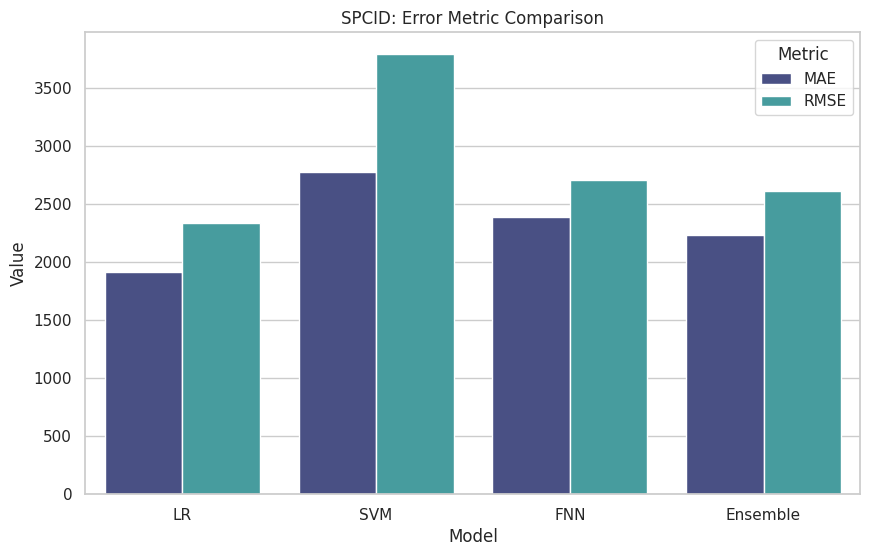

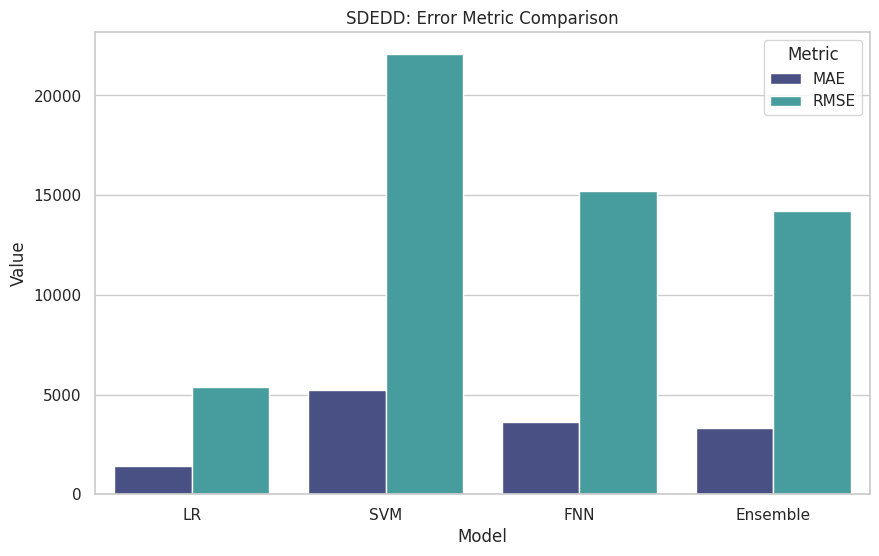

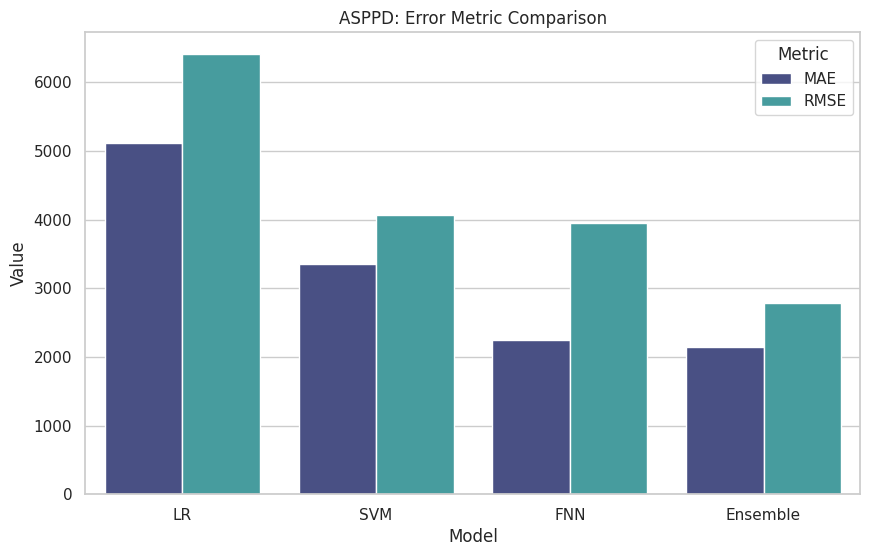

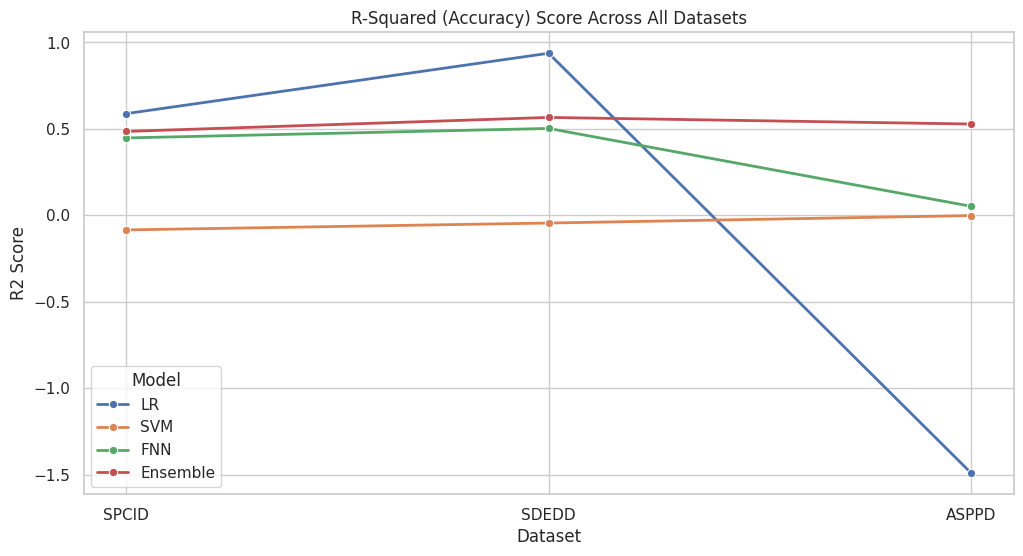

In [8]:
# ==========================================
# 1. INSTALLATION & IMPORTS
# ==========================================
!pip install scikit-fuzzy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import VotingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Setting visual styles
sns.set(style="whitegrid")

# Helper for RMSE calculation
def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ==========================================
# 2. GENETIC ALGORITHM (GA) ENGINE
# ==========================================
# This function evolves the best feature set for the dataset
def fitness_function(chromosome, X, y):
    selected_indices = [i for i, bit in enumerate(chromosome) if bit == 1]
    if len(selected_indices) == 0: return 999999
    # Fitness is based on minimizing the cross-validated MAE
    model = RandomForestRegressor(n_estimators=10, random_state=42)
    scores = cross_val_score(model, X[:, selected_indices], y, cv=3, scoring='neg_mean_absolute_error')
    return -scores.mean()

def genetic_feature_selection(X, y, dataset_name):
    num_features = X.shape[1]
    population_size = 10
    generations = 5 # Number of evolution steps

    # Initialize random population of chromosomes
    population = [np.random.randint(2, size=num_features) for _ in range(population_size)]

    print(f"\n[GA] Optimizing features for {dataset_name}...")
    for gen in range(generations):
        fitness_scores = [fitness_function(c, X, y) for c in population]
        best_indices = np.argsort(fitness_scores)[:4]
        parents = [population[i] for i in best_indices]

        # Breed next generation (Crossover & Mutation)
        new_pop = list(parents)
        while len(new_pop) < population_size:
            p1, p2 = random.sample(parents, 2)
            child = np.concatenate([p1[:num_features//2], p2[num_features//2:]])
            if random.random() < 0.1: # 10% Mutation rate
                child[random.randint(0, num_features-1)] = 1 - child[random.randint(0, num_features-1)]
            new_pop.append(child)
        population = new_pop
        print(f"  Generation {gen+1}: Best MAE = {min(fitness_scores):.2f}")

    return population[0]

# ==========================================
# 3. CORE HYBRID PIPELINE
# ==========================================
def execute_hybrid_pipeline(df, features, target, name):
    print(f"\n--- Processing {name} Pipeline ---")
    df = df.dropna()
    X_raw = df[features].values
    y = df[target].values

    # Feature Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # Step 1: Genetic Evolutionary Refinement
    best_chrom = genetic_feature_selection(X_scaled, y, name)
    X_ga = X_scaled[:, [i for i, b in enumerate(best_chrom) if b == 1]]

    # Step 2: PCA Dimensionality Reduction
    n_comp = min(X_ga.shape[1], 5)
    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(X_ga)

    # Step 3: Model Training
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    lr = LinearRegression().fit(X_train, y_train)
    svm = SVR(kernel='rbf').fit(X_train, y_train)
    fnn = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42).fit(X_train, y_train)

    # Ensemble (Voting)
    ensemble = VotingRegressor([('lr', lr), ('svm', svm), ('fnn', fnn)]).fit(X_train, y_train)

    # Step 4: Metric Calculation
    models = {"LR": lr, "SVM": svm, "FNN": fnn, "Ensemble": ensemble}
    results = {}
    for m_name, model in models.items():
        p = model.predict(X_test)
        results[m_name] = {
            "MAE": mean_absolute_error(y_test, p),
            "RMSE": get_rmse(y_test, p),
            "R2": r2_score(y_test, p),
            "Pred": p,
            "Actual": y_test
        }
    return results

# ==========================================
# 4. RUNNING ALL THREE DATASETS
# ==========================================
# SPCID Processing
df_spcid = pd.read_csv("SPCID.csv")
spcid_res = execute_hybrid_pipeline(df_spcid, ['TeamExp', 'ManagerExp', 'Length', 'Transactions', 'Entities', 'PointsAjust'], 'Effort', 'SPCID')

# SDEDD Processing
df_sdedd = pd.read_csv("SDEDD.csv")
sdedd_res = execute_hybrid_pipeline(df_sdedd, ['Actual.duration', 'Adjusted.function.points', 'First.estimate'], 'Actual.effort', 'SDEDD')

# ASPPD Processing
df_asppd = pd.read_csv("ASPPD.csv")
le = LabelEncoder()
for col in ['app', 'har', 'dba', 'ifc', 'source']: df_asppd[col] = le.fit_transform(df_asppd[col].astype(str))
asppd_feats = ['size_D', 'duration_D', 'app', 'har', 'dba'] + [f't{i:02d}' for i in range(1, 16)]
asppd_res = execute_hybrid_pipeline(df_asppd, asppd_feats, 'effort_D', 'ASPPD')

# ==========================================
# 5. GENERATING COMPARISON VISUALS
# ==========================================
def save_comparison_plot(results_dict, dataset_name):
    data = []
    for model, m in results_dict.items():
        data.append({"Model": model, "Metric": "MAE", "Value": m["MAE"]})
        data.append({"Model": model, "Metric": "RMSE", "Value": m["RMSE"]})
    df_plot = pd.DataFrame(data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_plot, x="Model", y="Value", hue="Metric", palette="mako")
    plt.title(f"{dataset_name}: Error Metric Comparison")
    plt.show()

# Visualize Each Dataset
save_comparison_plot(spcid_res, "SPCID")
save_comparison_plot(sdedd_res, "SDEDD")
save_comparison_plot(asppd_res, "ASPPD")

# Global R2 Comparison Chart
r2_list = []
for name, res in [("SPCID", spcid_res), ("SDEDD", sdedd_res), ("ASPPD", asppd_res)]:
    for m_name, m_val in res.items():
        r2_list.append({"Dataset": name, "Model": m_name, "R2 Score": m_val["R2"]})
df_r2 = pd.DataFrame(r2_list)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_r2, x="Dataset", y="R2 Score", hue="Model", marker="o", lw=2)
plt.title("R-Squared (Accuracy) Score Across All Datasets")
plt.show()